In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [24]:
df = pd.read_csv('HeartDiseaseTrain-Test.csv')

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


Cleaning Data

In [25]:
# Check shape, data types and missing values
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1025, 14)

Data Types:
 age                                int64
sex                               object
chest_pain_type                   object
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar               object
rest_ecg                          object
Max_heart_rate                     int64
exercise_induced_angina           object
oldpeak                          float64
slope                             object
vessels_colored_by_flourosopy     object
thalassemia                       object
target                             int64
dtype: object

Missing Values:
 age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope       

In [27]:
df = df.drop(columns=['target'])

In [26]:
print("Before:", df['thalassemia'].value_counts())
df = df[df['thalassemia'] != 'No']
print("\nAfter:", df['thalassemia'].value_counts())

Before: thalassemia
Fixed Defect         544
Reversable Defect    410
Normal                64
No                     7
Name: count, dtype: int64

After: thalassemia
Fixed Defect         544
Reversable Defect    410
Normal                64
Name: count, dtype: int64


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

text_columns = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',
    'rest_ecg',
    'exercise_induced_angina',
    'slope',
    'vessels_colored_by_flourosopy',
    'thalassemia'
]

for col in text_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia
0,52,1,3,125,212,1,2,168,0,1.0,0,3,2
1,53,1,3,140,203,0,1,155,1,3.1,2,4,2
2,70,1,3,145,174,1,2,125,1,2.6,2,4,2
3,61,1,3,148,203,1,2,161,0,0.0,0,1,2
4,62,0,3,138,294,0,2,106,0,1.9,1,2,0


In [29]:
print("Cleaned Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nThalassemia Classes:\n", df['thalassemia'].value_counts())

Cleaned Shape: (1018, 13)

Data Types:
 age                                int64
sex                                int64
chest_pain_type                    int64
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar                int64
rest_ecg                           int64
Max_heart_rate                     int64
exercise_induced_angina            int64
oldpeak                          float64
slope                              int64
vessels_colored_by_flourosopy      int64
thalassemia                        int64
dtype: object

Missing Values:
 age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_co

Visualising Data

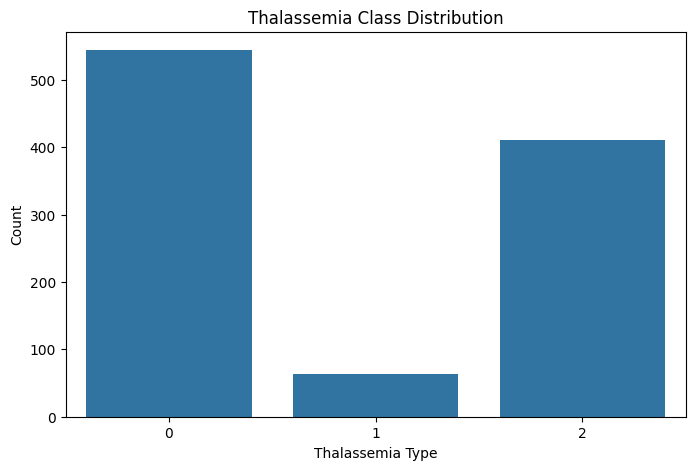

In [30]:
# See how many patients fall into each thalassemia class
plt.figure(figsize=(8, 5))
sns.countplot(x='thalassemia', data=df)
plt.title('Thalassemia Class Distribution')
plt.xlabel('Thalassemia Type')
# 0 = fixed defect, 1 = normal, 2 = reverseable defect.
plt.ylabel('Count')
plt.show()

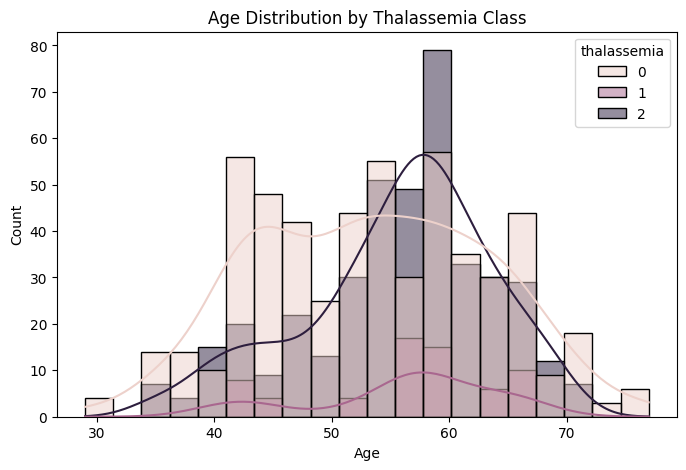

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='thalassemia', bins=20, kde=True)
plt.title('Age Distribution by Thalassemia Class')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

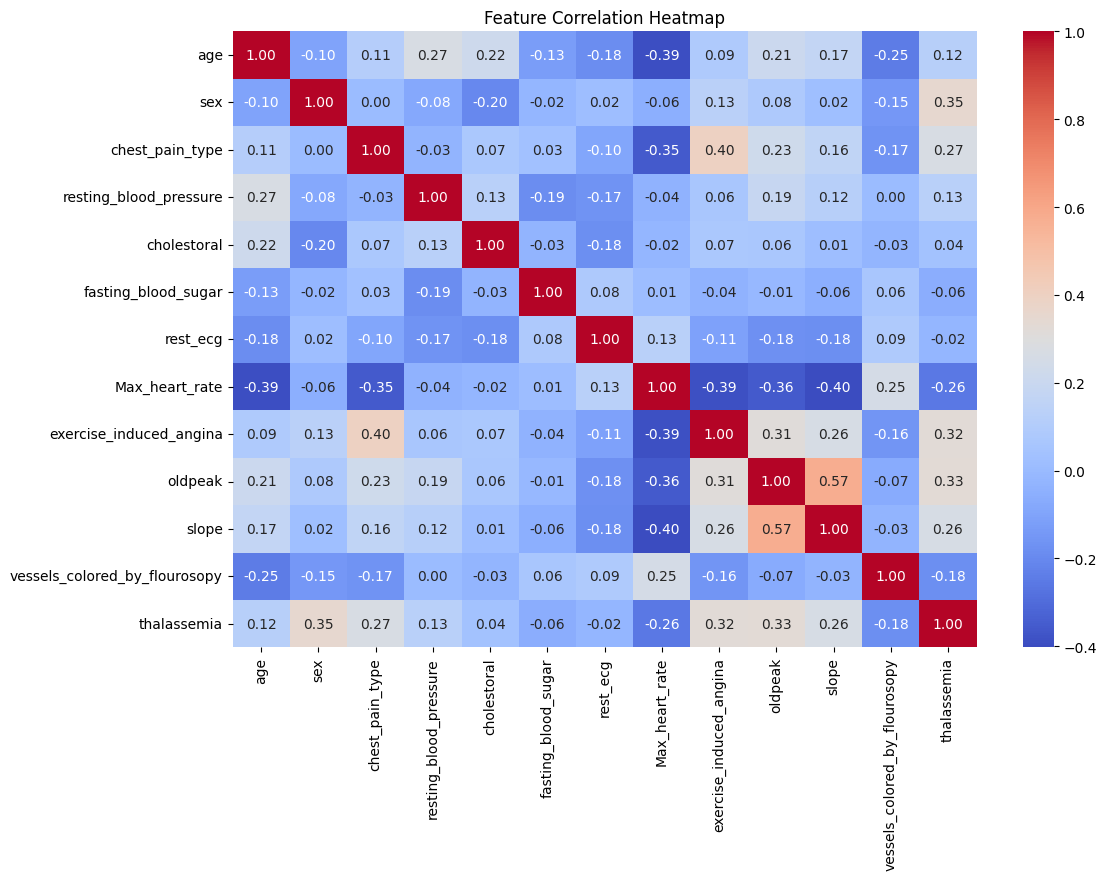

In [32]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

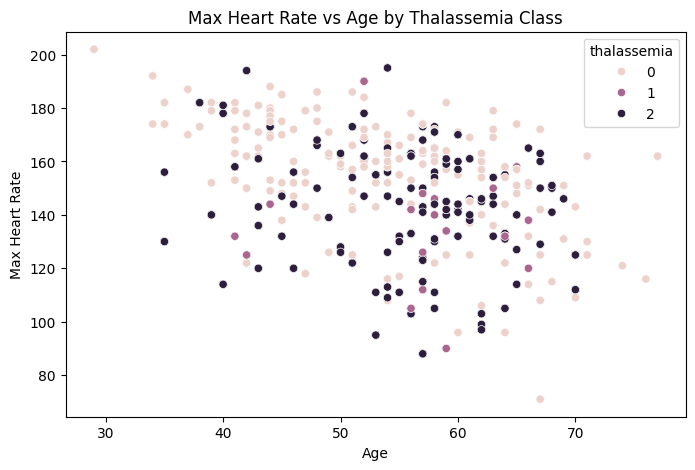

In [33]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='Max_heart_rate', hue='thalassemia')
plt.title('Max Heart Rate vs Age by Thalassemia Class')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.show()

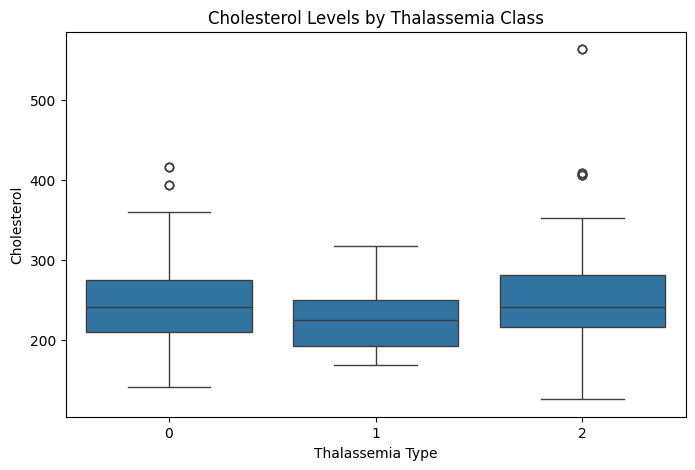

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='thalassemia', y='cholestoral')
plt.title('Cholesterol Levels by Thalassemia Class')
plt.xlabel('Thalassemia Type')
plt.ylabel('Cholesterol')
plt.show()

Split featrue and target

In [35]:
# X = all features, y = predict
X = df.drop(columns=['thalassemia'])
y = df['thalassemia']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1018, 12)
Target shape: (1018,)


Train and Test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (814, 12)
Testing set size: (204, 12)


Scaling feature

In [37]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


Handle imbalance in class

In [38]:

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6166666666666667), 1: np.float64(5.3202614379084965), 2: np.float64(0.8400412796697626)}


K nearest neighbours

In [39]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.76      0.86      0.81       104
           1       0.58      0.54      0.56        13
           2       0.76      0.66      0.70        87

    accuracy                           0.75       204
   macro avg       0.70      0.68      0.69       204
weighted avg       0.75      0.75      0.75       204



Naive bayes

In [40]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7009803921568627
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       104
           1       0.21      0.23      0.22        13
           2       0.70      0.61      0.65        87

    accuracy                           0.70       204
   macro avg       0.56      0.56      0.56       204
weighted avg       0.70      0.70      0.70       204



Logistic regression

In [41]:
lr = LogisticRegression(max_iter=1000, class_weight=class_weight_dict)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.6372549019607843
              precision    recall  f1-score   support

           0       0.87      0.75      0.80       104
           1       0.11      0.38      0.18        13
           2       0.67      0.54      0.60        87

    accuracy                           0.64       204
   macro avg       0.55      0.56      0.53       204
weighted avg       0.74      0.64      0.68       204



Support vector machine

In [42]:
svm = SVC(class_weight=class_weight_dict)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8676470588235294
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       104
           1       0.68      1.00      0.81        13
           2       0.86      0.83      0.84        87

    accuracy                           0.87       204
   macro avg       0.82      0.90      0.85       204
weighted avg       0.87      0.87      0.87       204



In [43]:
results = {
    'KNN': accuracy_score(y_test, knn_pred),
    'Naive Bayes': accuracy_score(y_test, nb_pred),
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'SVM': accuracy_score(y_test, svm_pred)
}

print("Model Comparison:")
print("-" * 30)
for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

print("-" * 30)
print(f"Best Model: {max(results, key=results.get)}")

Model Comparison:
------------------------------
KNN: 0.7500
Naive Bayes: 0.7010
Logistic Regression: 0.6373
SVM: 0.8676
------------------------------
Best Model: SVM


Neural network

In [54]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,491 (13.64 KB)

 Trainable params: 3,491 (13.64 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Training model

In [47]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2734 - loss: 1.0979 - val_accuracy: 0.5092 - val_loss: 1.0431
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5868 - loss: 0.9717 - val_accuracy: 0.6196 - val_loss: 0.9235
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6575 - loss: 0.8782 - val_accuracy: 0.6503 - val_loss: 0.8374
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6728 - loss: 0.7931 - val_accuracy: 0.6687 - val_loss: 0.7675
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7005 - loss: 0.7105 - val_accuracy: 0.6748 - val_loss: 0.7362
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7250 - loss: 0.6459 - val_accuracy: 0.6871 - val_loss: 0.6810
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7389 - loss: 0.5875 - val_accuracy: 0.6994 - val_loss: 0.6544
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7711 - loss: 0.5404 - val_accuracy: 0.6994 - 

Training history plot

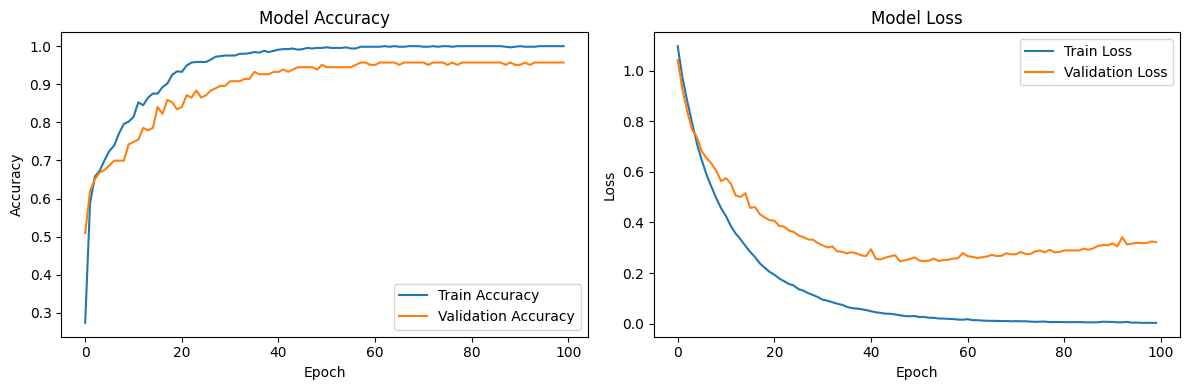

In [48]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Evalualtion

In [49]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Neural Network Test Accuracy:", test_accuracy)

nn_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, nn_pred))

Neural Network Test Accuracy: 0.9460784196853638
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       104
           1       0.83      0.77      0.80        13
           2       0.95      0.92      0.94        87

    accuracy                           0.95       204
   macro avg       0.91      0.89      0.90       204
weighted avg       0.95      0.95      0.95       204



In [50]:
results['Neural Network'] = test_accuracy

print("Final Model Comparison:")
print("-" * 30)
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")

print("-" * 30)
print(f"Best Model: {max(results, key=results.get)}")

Final Model Comparison:
------------------------------
KNN: 0.7500
Naive Bayes: 0.7010
Logistic Regression: 0.6373
SVM: 0.8676
Neural Network: 0.9461
------------------------------
Best Model: Neural Network


In [51]:
def predict_thalassemia(age, sex, chest_pain_type, resting_blood_pressure,
                         cholestoral, fasting_blood_sugar, rest_ecg,
                         max_heart_rate, exercise_induced_angina, oldpeak,
                         slope, vessels_colored_by_flourosopy):

    # Class labels
    thal_classes = {0: 'Fixed Defect', 1: 'Normal', 2: 'Reversable Defect'}

    # Create input array
    input_data = np.array([[age, sex, chest_pain_type, resting_blood_pressure,
                            cholestoral, fasting_blood_sugar, rest_ecg,
                            max_heart_rate, exercise_induced_angina, oldpeak,
                            slope, vessels_colored_by_flourosopy]])

    # Scale the input using the same scaler from training
    input_scaled = scaler.transform(input_data)

    # Get prediction
    prediction = np.argmax(model.predict(input_scaled), axis=1)[0]
    confidence = np.max(model.predict(input_scaled)) * 100

    print("=" * 40)
    print("       THALASSEMIA PREDICTION RESULT")
    print("=" * 40)
    print(f"Predicted Class:  {thal_classes[prediction]}")
    print(f"Confidence:       {confidence:.2f}%")
    print("=" * 40)

In [52]:
print("Use these encoded values when making predictions:")
print()
print("sex:                    Male=1, Female=0")
print("chest_pain_type:        Asymptomatic=0, Atypical angina=1,")
print("                        Non-anginal pain=2, Typical angina=3")
print("fasting_blood_sugar:    Greater than 120mg/ml=0,")
print("                        Lower than 120mg/ml=1")
print("rest_ecg:               Left ventricular hypertrophy=0,")
print("                        Normal=1, ST-T wave abnormality=2")
print("exercise_induced_angina: No=0, Yes=1")
print("slope:                  Downsloping=0, Flat=1, Upsloping=2")
print("vessels_colored_by_flourosopy: Four=0, One=1, Three=2,")
print("                               Two=3, Zero=4")

Use these encoded values when making predictions:

sex:                    Male=1, Female=0
chest_pain_type:        Asymptomatic=0, Atypical angina=1,
                        Non-anginal pain=2, Typical angina=3
fasting_blood_sugar:    Greater than 120mg/ml=0,
                        Lower than 120mg/ml=1
rest_ecg:               Left ventricular hypertrophy=0,
                        Normal=1, ST-T wave abnormality=2
exercise_induced_angina: No=0, Yes=1
slope:                  Downsloping=0, Flat=1, Upsloping=2
vessels_colored_by_flourosopy: Four=0, One=1, Three=2,
                               Two=3, Zero=4


In [53]:
predict_thalassemia(
    age=55,
    sex=1,                              # Male
    chest_pain_type=0,                  # Asymptomatic
    resting_blood_pressure=130,
    cholestoral=250,
    fasting_blood_sugar=1,              # Lower than 120 mg/ml
    rest_ecg=1,                         # Normal
    max_heart_rate=140,
    exercise_induced_angina=1,          # Yes
    oldpeak=1.5,
    slope=2,                            # Upsloping
    vessels_colored_by_flourosopy=4     # Zero vessels
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
       THALASSEMIA PREDICTION RESULT
Predicted Class:  Fixed Defect
Confidence:       97.68%
